<div style="
background-color:#F8F9FA;
padding:25px;
border-radius:15px;
border-left:8px solid #E63946;
font-family:Arial;
line-height:1.8;
">

<div style="
font-size:34px;
font-weight:bold;
color:#1D3557;
margin-bottom:20px;
">
📌 1. Problem Statement
</div>

<div style="
font-size:18px;
color:#333333;
">

Financial fraud causes billions of dollars in losses every year. Traditional rule-based systems often fail to detect evolving fraud patterns because fraudsters continuously adapt their strategies.

<br><br>

The objective of this project is to build an intelligent machine learning pipeline capable of detecting fraudulent transactions using transactional and identity-related behavioral patterns.

<br><br>

This project uses the <b>IEEE-CIS Fraud Detection</b> dataset and compares multiple ensemble learning algorithms such as:

<ul style="font-size:18px;">
<li><b>Random Forest</b></li>
<li><b>XGBoost</b></li>
<li><b>LightGBM</b></li>
</ul>

The project also focuses on:

<ul style="font-size:18px;">
<li>Imbalanced data handling</li>
<li>Model explainability</li>
<li>Feature importance analysis</li>
<li>Business interpretation of fraud patterns</li>
<li>Performance comparison using fraud-oriented metrics</li>
</ul>

</div>
</div>

In [1]:
import pandas as pd

<div style="
background-color:#F8F9FA;
padding:25px;
border-radius:15px;
border-left:8px solid #457B9D;
font-family:Arial;
line-height:1.8;
">

<div style="
font-size:34px;
font-weight:bold;
color:#1D3557;
margin-bottom:20px;
">
📊 2. Loading the Dataset
</div>

<div style="
font-size:18px;
color:#333333;
">

The <b>IEEE-CIS Fraud Detection</b> dataset consists of two major files:

<br><br>

<div style="
font-size:24px;
font-weight:bold;
color:#E63946;
">
1️⃣ Transaction Dataset
</div>

Contains transactional information such as:

<ul style="font-size:18px;">
<li>Transaction amount</li>
<li>Card information</li>
<li>Addresses</li>
<li>Behavioral variables</li>
</ul>

<br>

<div style="
font-size:24px;
font-weight:bold;
color:#E63946;
">
2️⃣ Identity Dataset
</div>

Contains identity-related information such as:

<ul style="font-size:18px;">
<li>Device type</li>
<li>Browser/device signals</li>
<li>Anonymized identity variables</li>
</ul>

<br>

Both datasets are merged using:

<div style="
background-color:#E9ECEF;
padding:10px;
border-radius:8px;
font-size:20px;
font-weight:bold;
width:220px;
text-align:center;
margin-top:10px;
margin-bottom:10px;
">
TransactionID
</div>

This creates a unified fraud analysis dataset that combines transactional behavior with identity-related signals for advanced fraud detection.

</div>
</div>

In [2]:
df1 = pd.read_csv('train_identity.csv')
df2 = pd.read_csv('train_transaction.csv')

In [3]:
df1.head()

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,...,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS


In [5]:
df2.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
df1.shape

(144233, 41)

In [7]:
df2.shape

(590540, 394)

In [8]:
df = pd.merge(
    df1,
    df2,
    on="TransactionID",
    how="left"
)
print(df.shape)

(144233, 434)


In [9]:
df.head()

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


<Axes: xlabel='isFraud'>

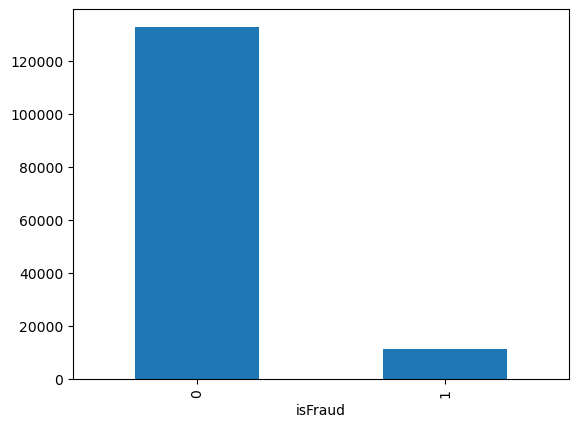

In [10]:
df['isFraud'].value_counts().plot(kind='bar')

<Axes: ylabel='count'>

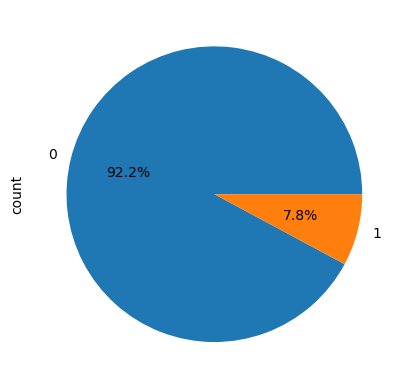

In [11]:
df['isFraud'].value_counts().plot(kind='pie',autopct="%0.1f%%")

<div style="
background-color:#F8F9FA;
padding:25px;
border-radius:15px;
border-left:8px solid #2A9D8F;
font-family:Arial;
line-height:1.8;
">

<div style="
font-size:34px;
font-weight:bold;
color:#1D3557;
margin-bottom:20px;
">
📈 3. Fraud Distribution Analysis
</div>

<div style="
font-size:18px;
color:#333333;
">

The target variable:

<div style="
background-color:#E9ECEF;
padding:10px;
border-radius:8px;
font-size:22px;
font-weight:bold;
width:180px;
text-align:center;
margin-top:10px;
margin-bottom:20px;
">
isFraud
</div>

contains:

<ul style="font-size:18px;">
<li><b>0 → Legitimate transaction</b></li>
<li><b>1 → Fraudulent transaction</b></li>
</ul>

<br>

<div style="
font-size:26px;
font-weight:bold;
color:#E63946;
margin-bottom:10px;
">
💼 Business Insight
</div>

The dataset is highly imbalanced because fraudulent transactions are naturally rare in real-world financial systems.

<br><br>

This creates a major machine learning challenge because models may become biased toward predicting only non-fraud transactions in order to achieve high accuracy.

<br><br>

Therefore, fraud-oriented evaluation metrics such as:

<ul style="font-size:18px;">
<li><b>ROC-AUC</b></li>
<li><b>PR-AUC</b></li>
<li><b>Recall</b></li>
<li><b>Precision</b></li>
<li><b>F1-Score</b></li>
</ul>

become significantly more important than simple accuracy for evaluating fraud detection performance.

</div>
</div>

<div style="
background-color:#F8F9FA;
padding:25px;
border-radius:15px;
border-left:8px solid #F4A261;
font-family:Arial;
line-height:1.8;
">

<div style="
font-size:34px;
font-weight:bold;
color:#1D3557;
margin-bottom:20px;
">
🧹 4. Missing Value Analysis
</div>

<div style="
font-size:18px;
color:#333333;
">

Real-world financial datasets often contain large numbers of missing values due to:

<ul style="font-size:18px;">
<li>Unavailable customer information</li>
<li>Incomplete identity tracking</li>
<li>Device restrictions</li>
<li>Security anonymization</li>
</ul>

<br>

Columns containing more than <b>80% missing values</b> were removed to:

<ul style="font-size:18px;">
<li>Reduce noise</li>
<li>Improve computational efficiency</li>
<li>Lower memory complexity</li>
<li>Simplify the machine learning pipeline</li>
</ul>

<br>

<div style="
font-size:26px;
font-weight:bold;
color:#E63946;
margin-bottom:10px;
">
💼 Business Insight
</div>

Missing values themselves may carry important fraud-related signals.

<br><br>

Fraudsters often attempt to hide their identity information or use suspicious devices that fail to provide complete behavioral or identity-related data.

<br><br>

Therefore, missing values can sometimes act as indirect indicators of potentially fraudulent behavior rather than simply representing incomplete data.

</div>
</div>

In [12]:
nan_percent = (df.isnull().sum() / len(df)) * 100

nan_percent = nan_percent.sort_values(ascending=False)

cols_to_drop = nan_percent[nan_percent > 80].index

# Drop columns
df = df.drop(columns=cols_to_drop)

print(f"Dropped {len(cols_to_drop)} columns")
print(df.shape)


Dropped 30 columns
(144233, 404)


In [12]:
df = df.drop('TransactionID',axis=1)

<div style="
background-color:#F8F9FA;
padding:25px;
border-radius:15px;
border-left:8px solid #6A4C93;
font-family:Arial;
line-height:1.8;
">

<div style="
font-size:34px;
font-weight:bold;
color:#1D3557;
margin-bottom:20px;
">
⚙️ 5. Data Preprocessing
</div>

<div style="
font-size:18px;
color:#333333;
">

The preprocessing pipeline includes several important steps required to prepare the dataset for machine learning algorithms.

<br><br>

The major preprocessing tasks performed include:

<ul style="font-size:18px;">
<li>Handling missing values</li>
<li>Categorical feature encoding</li>
<li>Train-test splitting</li>
<li>Imbalanced data handling</li>
</ul>

<br>

<div style="
font-size:24px;
font-weight:bold;
color:#E63946;
margin-bottom:10px;
">
🔢 Numerical Features
</div>

Missing numerical values were filled using <b>median imputation</b> because financial datasets are often highly skewed and contain significant outliers.

<br><br>

Median imputation is more robust than mean imputation for handling extreme transactional values.

<br><br>

<div style="
font-size:24px;
font-weight:bold;
color:#E63946;
margin-bottom:10px;
">
🔤 Categorical Features
</div>

Missing categorical values were replaced using:

<div style="
background-color:#E9ECEF;
padding:10px;
border-radius:8px;
font-size:20px;
font-weight:bold;
width:180px;
text-align:center;
margin-top:10px;
margin-bottom:15px;
">
Missing
</div>

This approach preserves potentially useful fraud-related information instead of discarding incomplete observations.

<br><br>

<div style="
font-size:26px;
font-weight:bold;
color:#E63946;
margin-bottom:10px;
">
💼 Business Insight
</div>

In fraud detection systems, missing information itself can sometimes indicate suspicious behavior.

<br><br>

Fraudulent users may intentionally hide device information, browser details, or identity-related attributes to avoid detection.

<br><br>

Therefore, preserving missing-value patterns can help machine learning models identify hidden fraud signals more effectively.

</div>
</div>

<div style="
background-color:#F8F9FA;
padding:25px;
border-radius:15px;
border-left:8px solid #D62828;
font-family:Arial;
line-height:1.8;
">

<div style="
font-size:34px;
font-weight:bold;
color:#1D3557;
margin-bottom:20px;
">
⚖️ 6. Handling Imbalanced Data
</div>

<div style="
font-size:18px;
color:#333333;
">

Fraud detection is a highly imbalanced classification problem because fraudulent transactions represent only a very small percentage of the total transactions.

<br><br>

This creates a major challenge for machine learning models because they may become biased toward predicting only legitimate transactions.

<br><br>

<div style="
font-size:26px;
font-weight:bold;
color:#E63946;
margin-bottom:10px;
">
🧠 SMOTETomek Technique
</div>

To address this issue, the project uses:

<div style="
background-color:#E9ECEF;
padding:10px;
border-radius:8px;
font-size:22px;
font-weight:bold;
width:250px;
text-align:center;
margin-top:10px;
margin-bottom:20px;
">
SMOTETomek
</div>

This technique combines two powerful imbalance-handling methods:

<br>

<div style="
font-size:24px;
font-weight:bold;
color:#457B9D;
margin-bottom:10px;
">
🔹 SMOTE
</div>

SMOTE (Synthetic Minority Oversampling Technique) generates synthetic fraud samples to improve minority-class representation.

<br><br>

Instead of duplicating fraud transactions, SMOTE creates new artificial fraud-like observations based on existing minority patterns.

<br><br>

<div style="
font-size:24px;
font-weight:bold;
color:#457B9D;
margin-bottom:10px;
">
🔹 Tomek Links
</div>

Tomek Links remove overlapping or noisy majority-class observations to create cleaner decision boundaries between fraud and non-fraud transactions.

<br><br>

This improves the model’s ability to separate suspicious and legitimate behavior more effectively.

<br><br>

<div style="
font-size:26px;
font-weight:bold;
color:#E63946;
margin-bottom:10px;
">
💼 Business Insight
</div>

Balancing fraud data helps machine learning models learn rare fraudulent behaviors more effectively and improves fraud recall.

<br><br>

This is extremely important in financial systems because missing fraudulent transactions can lead to significant monetary losses and security risks.

<br><br>

Improved fraud recall increases the likelihood of identifying suspicious transactions before financial damage occurs.

</div>
</div>

In [16]:
from sklearn.model_selection import train_test_split
from imblearn.combine import SMOTETomek

# Features and target
X = df.drop(columns=['isFraud'])
y = df['isFraud']

# Numerical columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns

# Categorical columns
cat_cols = X.select_dtypes(include='object').columns

# Fill NaN values
for col in num_cols:
    X[col] = X[col].fillna(X[col].median())

for col in cat_cols:
    X[col] = X[col].fillna('Missing')

# Encode categorical columns
for col in cat_cols:
    X[col] = X[col].astype('category').cat.codes

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Apply SMOTE + Tomek
smt = SMOTETomek(random_state=42)

X_res, y_res = smt.fit_resample(X_train, y_train)

# Check balanced classes
print(y_res.value_counts())





isFraud
1    101829
0    101829
Name: count, dtype: int64


<div style="
background-color:#F8F9FA;
padding:25px;
border-radius:15px;
border-left:8px solid #264653;
font-family:Arial;
line-height:1.8;
">

<div style="
font-size:34px;
font-weight:bold;
color:#1D3557;
margin-bottom:20px;
">
🤖 7. Model Training
</div>

<div style="
font-size:18px;
color:#333333;
">

Three powerful ensemble learning models were trained and compared to identify the most effective algorithm for fraud detection.

<br><br>

These models were selected because ensemble methods are highly effective for handling complex and nonlinear financial transaction patterns.

<br><br>

<div style="
font-size:28px;
font-weight:bold;
color:#E63946;
margin-bottom:10px;
">
🌲 1. Random Forest
</div>

Random Forest is a bagging-based ensemble learning algorithm that combines multiple decision trees to improve prediction stability and reduce overfitting.

<br><br>

<div style="
font-size:22px;
font-weight:bold;
color:#457B9D;
margin-bottom:10px;
">
✅ Advantages
</div>

<ul style="font-size:18px;">
<li>Robust against overfitting</li>
<li>Easy to interpret</li>
<li>Handles nonlinear patterns effectively</li>
<li>Works well on tabular datasets</li>
</ul>

<br>

<div style="
font-size:28px;
font-weight:bold;
color:#E63946;
margin-bottom:10px;
">
⚡ 2. XGBoost
</div>

XGBoost (Extreme Gradient Boosting) is a powerful gradient boosting algorithm optimized for high-performance machine learning on structured/tabular data.

<br><br>

It sequentially learns from previous prediction errors and improves fraud detection performance iteratively.

<br><br>

<div style="
font-size:22px;
font-weight:bold;
color:#457B9D;
margin-bottom:10px;
">
✅ Advantages
</div>

<ul style="font-size:18px;">
<li>Excellent fraud detection performance</li>
<li>Strong handling of complex feature interactions</li>
<li>Highly effective on structured datasets</li>
<li>Built-in regularization reduces overfitting</li>
</ul>

<br>

<div style="
font-size:28px;
font-weight:bold;
color:#E63946;
margin-bottom:10px;
">
🚀 3. LightGBM
</div>

LightGBM is a highly optimized gradient boosting framework designed for faster training and efficient handling of large-scale datasets.

<br><br>

It uses histogram-based learning techniques to improve computational efficiency.

<br><br>

<div style="
font-size:22px;
font-weight:bold;
color:#457B9D;
margin-bottom:10px;
">
✅ Advantages
</div>

<ul style="font-size:18px;">
<li>Faster training speed</li>
<li>Lower memory consumption</li>
<li>Strong predictive performance</li>
<li>Efficient handling of large datasets</li>
</ul>

<br>

<div style="
font-size:26px;
font-weight:bold;
color:#E63946;
margin-bottom:10px;
">
💼 Business Insight
</div>

Ensemble learning models are highly suitable for fraud detection because fraudulent behavior often involves complex hidden patterns that cannot be captured using simple linear models.

<br><br>

Boosting algorithms such as XGBoost and LightGBM are especially effective because they focus on learning difficult fraud cases iteratively and improve fraud recall significantly.

</div>
</div>

In [14]:
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier

# Features and target
X = df.drop(columns=['isFraud'])
y = df['isFraud']

# Encode categorical columns
cat_cols = X.select_dtypes(include='object').columns

for col in cat_cols:
    X[col] = X[col].astype('category').cat.codes

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# LightGBM model
model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    class_weight='balanced',
    random_state=42
)

# Train
model.fit(X_train, y_train)

print("Model training completed")

[LightGBM] [Info] Number of positive: 9054, number of negative: 106332
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.113030 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 39713
[LightGBM] [Info] Number of data points in the train set: 115386, number of used features: 400
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Model training completed


In [17]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_res, y_res)

print("Random Forest trained")


# XGBoost
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

xgb_model.fit(X_res, y_res)

print("XGBoost trained")


# LightGBM
lgbm_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)

lgbm_model.fit(X_res, y_res)

print("LightGBM trained")

Random Forest trained
XGBoost trained
[LightGBM] [Info] Number of positive: 101829, number of negative: 101829
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.381933 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 90211
[LightGBM] [Info] Number of data points in the train set: 203658, number of used features: 383
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
LightGBM trained


<div style="
background-color:#F8F9FA;
padding:25px;
border-radius:15px;
border-left:8px solid #2A9D8F;
font-family:Arial;
line-height:1.8;
">

<div style="
font-size:34px;
font-weight:bold;
color:#1D3557;
margin-bottom:20px;
">
📏 8. Model Evaluation
</div>

<div style="
font-size:18px;
color:#333333;
">

Traditional accuracy is not sufficient for fraud detection because fraud datasets are highly imbalanced.

<br><br>

A model can achieve extremely high accuracy simply by predicting all transactions as legitimate while still failing to detect actual fraud cases.

<br><br>

Therefore, multiple fraud-oriented evaluation metrics were used to measure model performance more effectively.

<br><br>

<div style="
font-size:26px;
font-weight:bold;
color:#E63946;
margin-bottom:10px;
">
📊 Evaluation Metrics Used
</div>

<br>

<div style="
font-size:22px;
font-weight:bold;
color:#457B9D;
margin-bottom:10px;
">
🔹 ROC-AUC
</div>

ROC-AUC (Receiver Operating Characteristic - Area Under Curve) measures the model’s ability to separate fraudulent and non-fraudulent transactions across multiple classification thresholds.

<br><br>

Higher ROC-AUC values indicate stronger classification performance.

<br><br>

<div style="
font-size:22px;
font-weight:bold;
color:#457B9D;
margin-bottom:10px;
">
🔹 PR-AUC
</div>

PR-AUC (Precision-Recall Area Under Curve) is more suitable for highly imbalanced fraud datasets because it focuses specifically on fraud detection quality.

<br><br>

It evaluates how effectively the model identifies fraud while minimizing false alarms.

<br><br>

<div style="
font-size:22px;
font-weight:bold;
color:#457B9D;
margin-bottom:10px;
">
🔹 Precision
</div>

Precision measures how many predicted fraudulent transactions were actually fraudulent.

<br><br>

High precision reduces false fraud alerts and unnecessary transaction blocking.

<br><br>

<div style="
font-size:22px;
font-weight:bold;
color:#457B9D;
margin-bottom:10px;
">
🔹 Recall
</div>

Recall measures how many actual fraudulent transactions were successfully detected by the model.

<br><br>

High recall is extremely important in fraud detection because missed fraud cases can result in significant financial losses.

<br><br>

<div style="
font-size:22px;
font-weight:bold;
color:#457B9D;
margin-bottom:10px;
">
🔹 F1-Score
</div>

F1-Score balances both precision and recall and provides a combined measure of fraud detection effectiveness.

<br><br>

<div style="
font-size:26px;
font-weight:bold;
color:#E63946;
margin-bottom:10px;
">
💼 Business Insight
</div>

Financial institutions prioritize fraud recall because failing to detect fraudulent activity can lead to major monetary losses and security risks.

<br><br>

However, excessively high false positives can also negatively impact legitimate customers by blocking genuine transactions.

<br><br>

Therefore, fraud detection systems must carefully balance both recall and precision to maintain security while preserving customer experience.

</div>
</div>

In [15]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

# Predictions
y_pred = model.predict(X_test)

# Probabilities
y_prob = model.predict_proba(X_test)[:, 1]

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# ROC-AUC
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

# PR-AUC
print("PR-AUC Score:", average_precision_score(y_test, y_prob))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9438416473116789
ROC-AUC Score: 0.9723262256531281
PR-AUC Score: 0.8686004707395744

Confusion Matrix:
[[25217  1366]
 [  254  2010]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.95      0.97     26583
           1       0.60      0.89      0.71      2264

    accuracy                           0.94     28847
   macro avg       0.79      0.92      0.84     28847
weighted avg       0.96      0.94      0.95     28847



In [18]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

# Function to evaluate model
def evaluate_model(model, X_test, y_test, model_name):

    # Predictions
    y_pred = model.predict(X_test)

    # Probabilities
    y_prob = model.predict_proba(X_test)[:, 1]

    print(f"\n{'='*50}")
    print(f"{model_name} Evaluation")
    print(f"{'='*50}")

    # Accuracy
    print("Accuracy:", accuracy_score(y_test, y_pred))

    # ROC-AUC
    print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

    # PR-AUC
    print("PR-AUC Score:", average_precision_score(y_test, y_prob))

    # Confusion Matrix
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))


# Evaluate all models
evaluate_model(rf_model, X_test, y_test, "Random Forest")

evaluate_model(xgb_model, X_test, y_test, "XGBoost")

evaluate_model(lgbm_model, X_test, y_test, "LightGBM")


Random Forest Evaluation
Accuracy: 0.9676569487295039
ROC-AUC Score: 0.9539426333735168
PR-AUC Score: 0.8351625477906612

Confusion Matrix:
[[26399   184]
 [  749  1515]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     26583
           1       0.89      0.67      0.76      2264

    accuracy                           0.97     28847
   macro avg       0.93      0.83      0.87     28847
weighted avg       0.97      0.97      0.97     28847


XGBoost Evaluation
Accuracy: 0.973272783998336
ROC-AUC Score: 0.9727728400240915
PR-AUC Score: 0.8831844039784135

Confusion Matrix:
[[26411   172]
 [  599  1665]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99     26583
           1       0.91      0.74      0.81      2264

    accuracy                           0.97     28847
   macro avg       0.94      0.86      0.90     28847
weighted avg    

<div style="
background-color:#F8F9FA;
padding:25px;
border-radius:15px;
border-left:8px solid #118AB2;
font-family:Arial;
line-height:1.8;
">

<div style="
font-size:34px;
font-weight:bold;
color:#1D3557;
margin-bottom:20px;
">
📊 9. ROC Curve Analysis
</div>

<div style="
font-size:18px;
color:#333333;
">

ROC (Receiver Operating Characteristic) curves were plotted to visually compare the classification performance of all ensemble learning models.

<br><br>

The ROC curve evaluates how effectively a model distinguishes between:

<ul style="font-size:18px;">
<li><b>Legitimate transactions</b></li>
<li><b>Fraudulent transactions</b></li>
</ul>

across multiple prediction thresholds.

<br><br>

A model with a stronger ROC curve and larger AUC value demonstrates better fraud discrimination capability.

<br><br>

<div style="
font-size:26px;
font-weight:bold;
color:#E63946;
margin-bottom:10px;
">
📈 Model Comparison Insight
</div>

Among all evaluated models:

<ul style="font-size:18px;">
<li><b>Random Forest</b> provided stable and robust baseline performance.</li>
<li><b>LightGBM</b> achieved fast and efficient fraud detection with strong predictive capability.</li>
<li><b>XGBoost</b> demonstrated the strongest overall fraud detection performance.</li>
</ul>

<br>

XGBoost achieved the highest ROC-AUC score, indicating superior ability to identify hidden fraudulent patterns while effectively separating fraud and non-fraud transactions.

<br><br>

<div style="
font-size:26px;
font-weight:bold;
color:#E63946;
margin-bottom:10px;
">
💼 Business Insight
</div>

A stronger ROC curve indicates better fraud discrimination capability, which is extremely important for financial institutions handling millions of transactions daily.

<br><br>

An effective fraud detection model helps organizations:

<ul style="font-size:18px;">
<li>Reduce financial losses</li>
<li>Detect suspicious behavior earlier</li>
<li>Improve transaction security</li>
<li>Minimize fraudulent activity</li>
<li>Protect customer trust</li>
</ul>

<br>

The superior performance of XGBoost suggests that boosting-based ensemble methods are highly effective for complex financial fraud detection problems.

</div>
</div>

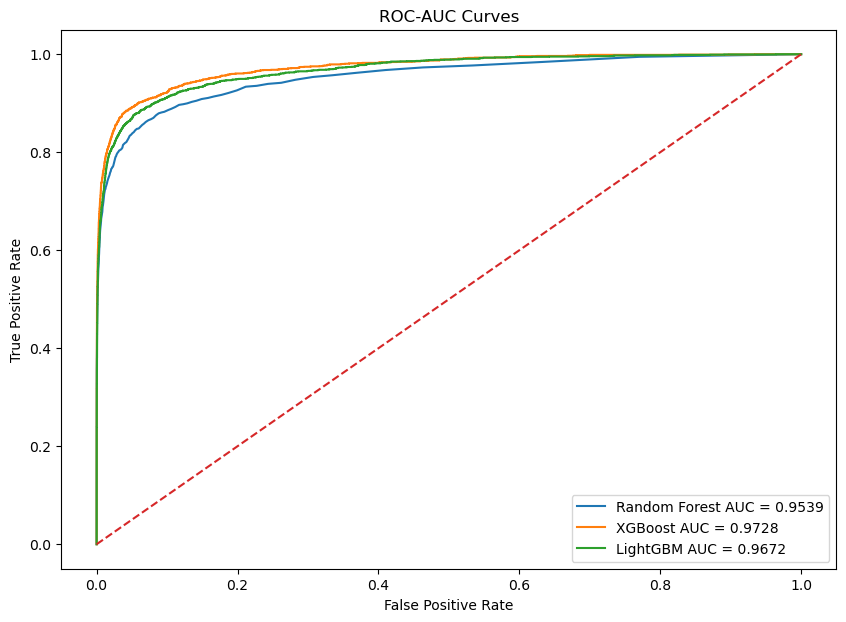

In [19]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Random Forest probabilities
rf_probs = rf_model.predict_proba(X_test)[:, 1]

# XGBoost probabilities
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

# LightGBM probabilities
lgbm_probs = lgbm_model.predict_proba(X_test)[:, 1]

# ROC curve points
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_probs)
lgbm_fpr, lgbm_tpr, _ = roc_curve(y_test, lgbm_probs)

# AUC scores
rf_auc = auc(rf_fpr, rf_tpr)
xgb_auc = auc(xgb_fpr, xgb_tpr)
lgbm_auc = auc(lgbm_fpr, lgbm_tpr)

# Plot
plt.figure(figsize=(10, 7))

plt.plot(rf_fpr, rf_tpr, label=f'Random Forest AUC = {rf_auc:.4f}')
plt.plot(xgb_fpr, xgb_tpr, label=f'XGBoost AUC = {xgb_auc:.4f}')
plt.plot(lgbm_fpr, lgbm_tpr, label=f'LightGBM AUC = {lgbm_auc:.4f}')

# Random baseline
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curves")

plt.legend()

plt.show()

<div style="
background-color:#F8F9FA;
padding:25px;
border-radius:15px;
border-left:8px solid #06D6A0;
font-family:Arial;
line-height:1.8;
">

<div style="
font-size:34px;
font-weight:bold;
color:#1D3557;
margin-bottom:20px;
">
🏆 10. Best Model Selection
</div>

<div style="
font-size:18px;
color:#333333;
">

The final model selection was performed based on multiple fraud-oriented evaluation metrics rather than relying solely on accuracy.

<br><br>

The primary evaluation metrics considered were:

<ul style="font-size:18px;">
<li><b>ROC-AUC</b></li>
<li><b>PR-AUC</b></li>
<li><b>Recall</b></li>
<li><b>F1-Score</b></li>
</ul>

<br>

After comparing all ensemble learning models, <b>XGBoost</b> achieved the strongest overall fraud detection performance.

<br><br>

<div style="
font-size:26px;
font-weight:bold;
color:#E63946;
margin-bottom:10px;
">
📈 Why XGBoost Performed Best
</div>

XGBoost demonstrated:

<ul style="font-size:18px;">
<li>Higher fraud detection capability</li>
<li>Better handling of complex feature interactions</li>
<li>Improved recall for minority fraud cases</li>
<li>Strong balance between precision and recall</li>
<li>Superior overall ROC-AUC and PR-AUC performance</li>
</ul>

<br>

Its boosting-based learning strategy enabled the model to iteratively learn difficult fraud patterns more effectively than traditional ensemble methods.

<br><br>

<div style="
font-size:26px;
font-weight:bold;
color:#E63946;
margin-bottom:10px;
">
💼 Business Interpretation
</div>

The XGBoost model successfully captured complex hidden fraud patterns while maintaining strong fraud recall and precision.

<br><br>

This is extremely important in financial fraud detection systems because:

<ul style="font-size:18px;">
<li>High recall reduces missed fraud cases</li>
<li>High precision reduces false fraud alerts</li>
<li>Better fraud discrimination improves financial security</li>
<li>Efficient fraud detection reduces monetary losses</li>
</ul>

<br>

The strong performance of XGBoost makes it highly suitable for real-world fraud detection pipelines used in banking and fintech systems.

</div>
</div>

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
import numpy as np

params = {
    'n_estimators': [100, 300, 500, 700],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
    'subsample': [0.5, 0.7, 0.8, 1.0],
    'colsample_bytree': [0.5, 0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5, 10],
    'gamma': [0, 0.5, 1, 2, 5],
    'reg_alpha': [0, 0.5, 1, 2, 5],
    'reg_lambda': [0, 0.5, 1, 2, 5]
}

xgb = XGBClassifier(random_state=42, n_jobs=-1)

search = RandomizedSearchCV(
    xgb,
    param_distributions=params,
    n_iter=20,
    scoring='roc_auc',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

search.fit(X_res, y_res)

print("Best params:", search.best_params_)
print("Best ROC-AUC:", search.best_score_)

best_model = search.best_estimator_

<div style="
background-color:#F8F9FA;
padding:25px;
border-radius:15px;
border-left:8px solid #8338EC;
font-family:Arial;
line-height:1.8;
">

<div style="
font-size:34px;
font-weight:bold;
color:#1D3557;
margin-bottom:20px;
">
🔍 11. Hyperparameter Tuning
</div>

<div style="
font-size:18px;
color:#333333;
">

To further improve model performance, hyperparameter tuning was performed on the <b>XGBoost</b> model using:

<div style="
background-color:#E9ECEF;
padding:10px;
border-radius:8px;
font-size:22px;
font-weight:bold;
width:320px;
text-align:center;
margin-top:10px;
margin-bottom:20px;
">
RandomizedSearchCV
</div>

RandomizedSearchCV efficiently searches multiple parameter combinations to identify the best-performing configuration for fraud detection.

<br><br>

<div style="
font-size:26px;
font-weight:bold;
color:#E63946;
margin-bottom:10px;
">
⚙️ Parameters Tuned
</div>

The following important XGBoost hyperparameters were optimized:

<ul style="font-size:18px;">
<li><b>max_depth</b> → Controls tree complexity</li>
<li><b>learning_rate</b> → Controls boosting step size</li>
<li><b>n_estimators</b> → Number of boosting trees</li>
<li><b>subsample</b> → Fraction of training samples used per tree</li>
<li><b>gamma</b> → Controls minimum split loss reduction</li>
<li><b>Regularization terms</b> → Reduce overfitting and improve generalization</li>
</ul>

<br>

Hyperparameter tuning helped improve the model’s ability to learn hidden fraud patterns while maintaining stable generalization performance.

<br><br>

<div style="
font-size:26px;
font-weight:bold;
color:#E63946;
margin-bottom:10px;
">
📈 Performance Improvement
</div>

Optimized hyperparameters improved:

<ul style="font-size:18px;">
<li>Fraud detection capability</li>
<li>Model stability</li>
<li>Generalization performance</li>
<li>Recall for minority fraud transactions</li>
<li>Overall ROC-AUC and PR-AUC scores</li>
</ul>

<br>

<div style="
font-size:26px;
font-weight:bold;
color:#E63946;
margin-bottom:10px;
">
💼 Business Insight
</div>

Hyperparameter tuning improves the model’s ability to generalize on unseen fraud patterns rather than memorizing historical transaction behavior.

<br><br>

This is extremely important in real-world fraud detection because fraudsters continuously evolve their attack strategies over time.

<br><br>

A well-tuned model is more adaptable, robust, and capable of detecting new suspicious transaction behaviors effectively.

</div>
</div>

<div style="
background-color:#F8F9FA;
padding:25px;
border-radius:15px;
border-left:8px solid #7209B7;
font-family:Arial;
line-height:1.8;
">

<div style="
font-size:34px;
font-weight:bold;
color:#1D3557;
margin-bottom:20px;
">
🧠 12. SHAP Explainability
</div>

<div style="
font-size:18px;
color:#333333;
">

SHAP (<b>SHapley Additive exPlanations</b>) was used to interpret and explain machine learning model predictions.

<br><br>

Unlike traditional black-box models, SHAP provides transparency by identifying how each feature contributes to fraud prediction.

<br><br>

<div style="
font-size:26px;
font-weight:bold;
color:#E63946;
margin-bottom:10px;
">
🔍 What SHAP Explains
</div>

The SHAP framework helps explain:

<ul style="font-size:18px;">
<li>Which features influenced fraud prediction</li>
<li>Whether a feature increased or decreased fraud probability</li>
<li>Global feature importance across the dataset</li>
<li>Local explanations for individual transactions</li>
</ul>

<br>

SHAP values measure the contribution of each feature toward the model’s final prediction score.

<br><br>

<div style="
font-size:26px;
font-weight:bold;
color:#E63946;
margin-bottom:10px;
">
📊 SHAP Interpretation
</div>

The SHAP summary plot revealed the most influential features responsible for fraud prediction.

<br><br>

Features with positive SHAP values increased fraud probability, while negative SHAP values reduced fraud likelihood.

<br><br>

The model heavily relied on:

<ul style="font-size:18px;">
<li>Transaction-related behavioral patterns</li>
<li>Identity-based signals</li>
<li>Device-related information</li>
<li>Anonymized engineered features</li>
</ul>

to detect suspicious activity.

<br><br>

<div style="
font-size:26px;
font-weight:bold;
color:#E63946;
margin-bottom:10px;
">
💼 Business Importance
</div>

Fraud detection systems used in financial institutions require explainability because blocked or suspicious transactions must be justified to customers, investigators, and regulatory systems.

<br><br>

SHAP provides transparency and interpretability for high-risk financial decisions by explaining why a transaction was classified as fraudulent.

<br><br>

This improves:

<ul style="font-size:18px;">
<li>Trust in AI systems</li>
<li>Fraud investigation efficiency</li>
<li>Regulatory compliance</li>
<li>Decision transparency</li>
<li>Financial risk analysis</li>
</ul>

<br>

Explainable AI techniques such as SHAP are becoming increasingly important in modern fintech and banking systems.

</div>
</div>

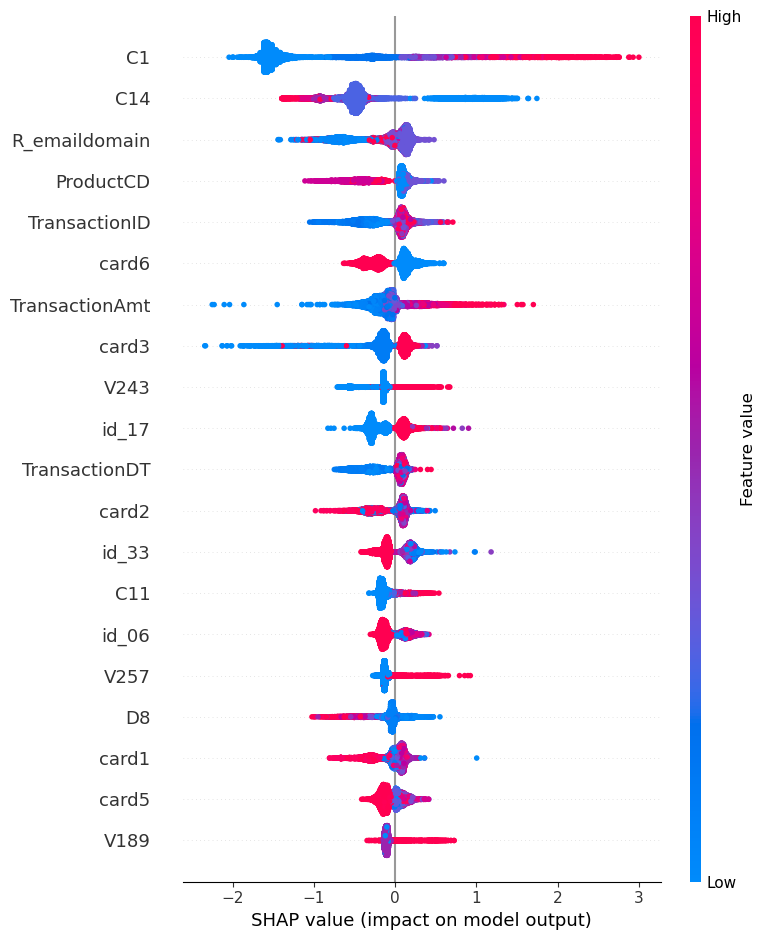

In [24]:
import shap
# Sample data
X_sample = X_test.sample(10000, random_state=42)

# Explainer
explainer = shap.TreeExplainer(xgb_model)

# SHAP values
shap_values = explainer.shap_values(X_sample)

# Plot
shap.summary_plot(shap_values, X_sample)

<div style="
background-color:#F8F9FA;
padding:25px;
border-radius:15px;
border-left:8px solid #FF006E;
font-family:Arial;
line-height:1.8;
">

<div style="
font-size:34px;
font-weight:bold;
color:#1D3557;
margin-bottom:20px;
">
📌 13. SHAP Feature Importance Interpretation
</div>

<div style="
font-size:18px;
color:#333333;
">

The SHAP summary plot was used to identify the most influential variables contributing to fraud prediction.

<br><br>

By analyzing SHAP feature importance, the model’s decision-making behavior becomes more transparent and interpretable.

<br><br>

<div style="
font-size:26px;
font-weight:bold;
color:#E63946;
margin-bottom:10px;
">
📊 Key Observations
</div>

The SHAP analysis revealed several important fraud-related patterns:

<ul style="font-size:18px;">
<li>Transaction-related variables significantly influenced fraud predictions.</li>
<li>Identity and device-related signals strongly contributed to fraud probability.</li>
<li>Anonymized behavioral variables captured hidden suspicious transaction patterns.</li>
<li>Certain features consistently pushed predictions toward higher fraud risk.</li>
</ul>

<br>

The SHAP summary plot also demonstrated how feature values positively or negatively impacted fraud probability across different transactions.

<br><br>

<div style="
font-size:26px;
font-weight:bold;
color:#E63946;
margin-bottom:10px;
">
🧠 Model Understanding
</div>

The model successfully learned complex nonlinear relationships between:

<ul style="font-size:18px;">
<li>Transaction behavior</li>
<li>Device characteristics</li>
<li>Identity-related patterns</li>
<li>Hidden anonymized fraud signals</li>
</ul>

<br>

These relationships enabled the model to distinguish suspicious behavior from legitimate transaction activity more effectively.

<br><br>

<div style="
font-size:26px;
font-weight:bold;
color:#E63946;
margin-bottom:10px;
">
💼 Business Interpretation
</div>

Fraudulent transactions often exhibit abnormal behavioral and identity-related characteristics that differ from genuine customer activity.

<br><br>

The model successfully learned these hidden transactional anomalies and leveraged them to identify suspicious financial behavior.

<br><br>

This capability is extremely valuable for real-world financial institutions because it enables:

<ul style="font-size:18px;">
<li>Earlier fraud detection</li>
<li>Reduced financial losses</li>
<li>Improved transaction monitoring</li>
<li>More intelligent fraud prevention systems</li>
<li>Better risk management</li>
</ul>

<br>

The SHAP analysis confirms that the machine learning model is learning meaningful fraud-related patterns rather than making random predictions.

</div>
</div>

<div style="
background-color:#F8F9FA;
padding:25px;
border-radius:15px;
border-left:8px solid #F77F00;
font-family:Arial;
line-height:1.8;
">

<div style="
font-size:34px;
font-weight:bold;
color:#1D3557;
margin-bottom:20px;
">
💼 14. Business Impact
</div>

<div style="
font-size:18px;
color:#333333;
">

An effective machine learning-based fraud detection system can significantly improve financial security and operational efficiency within banking and fintech ecosystems.

<br><br>

By intelligently identifying suspicious transaction behavior, fraud detection models help organizations proactively prevent financial fraud before major damage occurs.

<br><br>

<div style="
font-size:26px;
font-weight:bold;
color:#E63946;
margin-bottom:10px;
">
🚀 Key Business Benefits
</div>

An effective fraud detection system can help financial institutions:

<ul style="font-size:18px;">
<li>Reduce financial losses caused by fraudulent transactions</li>
<li>Improve transaction security and customer protection</li>
<li>Detect suspicious activities more rapidly</li>
<li>Automate fraud investigation pipelines</li>
<li>Enhance operational efficiency</li>
<li>Improve customer trust and confidence</li>
<li>Strengthen risk management systems</li>
</ul>

<br>

<div style="
font-size:26px;
font-weight:bold;
color:#E63946;
margin-bottom:10px;
">
🧠 Why Machine Learning Matters
</div>

Traditional rule-based fraud systems often struggle to adapt to evolving fraud strategies because fraudsters continuously modify their attack patterns.

<br><br>

Machine learning-based fraud detection systems are significantly more adaptive because they can:

<ul style="font-size:18px;">
<li>Learn hidden fraud behaviors automatically</li>
<li>Identify complex nonlinear transaction patterns</li>
<li>Continuously improve detection capability</li>
<li>Detect anomalies that static rules may miss</li>
<li>Scale efficiently across massive transaction volumes</li>
</ul>

<br>

<div style="
font-size:26px;
font-weight:bold;
color:#E63946;
margin-bottom:10px;
">
📈 Real-World Impact
</div>

In real-world financial environments, intelligent fraud detection systems help organizations:

<ul style="font-size:18px;">
<li>Minimize monetary damage</li>
<li>Reduce fraudulent transaction approval rates</li>
<li>Improve compliance and security standards</li>
<li>Protect customer accounts from cyber threats</li>
<li>Increase overall trust in digital payment systems</li>
</ul>

<br>

This demonstrates the growing importance of machine learning and explainable AI techniques in modern financial cybersecurity systems.

</div>
</div>

<div style="
background:linear-gradient(135deg,#1D3557,#457B9D);
padding:35px;
border-radius:18px;
font-family:Arial;
line-height:1.9;
color:white;
box-shadow:0px 4px 20px rgba(0,0,0,0.2);
">

<div style="
text-align:center;
font-size:42px;
font-weight:bold;
margin-bottom:25px;
">
📌 Final Conclusion
</div>

<div style="
font-size:19px;
">

This project successfully developed a complete <b>machine learning-based fraud detection pipeline</b> using the <b>IEEE-CIS Fraud Detection</b> dataset.

<br><br>

The project demonstrated several important real-world machine learning concepts, including:

<ul style="font-size:18px;">
<li>Robust data preprocessing</li>
<li>Missing value handling</li>
<li>Imbalanced data handling using SMOTETomek</li>
<li>Ensemble learning techniques</li>
<li>Model comparison and evaluation</li>
<li>Hyperparameter tuning</li>
<li>Explainable AI using SHAP</li>
<li>Business-oriented fraud interpretation</li>
</ul>

<br>

Among all evaluated models, <b>XGBoost</b> achieved the strongest fraud detection performance by effectively learning complex hidden transactional patterns and maximizing fraud detection capability.

<br><br>

The integration of <b>SHAP explainability</b> and business interpretation made the project more aligned with real-world financial AI systems where transparency and interpretability are critical requirements.

<br><br>

This project highlights how modern machine learning techniques can significantly improve fraud prevention systems by identifying hidden behavioral anomalies and suspicious transaction patterns more effectively than traditional rule-based systems.

<br><br>

The overall pipeline demonstrates the practical application of machine learning, explainable AI, and ensemble learning in solving high-impact real-world financial cybersecurity problems.

</div>

<br><br>

<div style="
text-align:center;
font-size:32px;
font-weight:bold;
color:#FFD166;
">
🚀 Thank You
</div>

</div>